In [1]:
#This code is used if the notebook is implemented in github codespace. Just remove the (#)
!python -m pip install .. --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step 1: Import GEE account setting from luma-stack

In [2]:
# Use EE initialization from luma_ge
import ee 
import luma_ge

# Autheticate using service account (json file)

service_account_path = '../auth/ee-epstm2024.json'
success = luma_ge.initialize_with_service_account(service_account_path)

if success:
    print("Earth Engine initialized with service account successfully!")
else:
    print("Service account initialization failed. Try to authenticate earth engine manually")

#Check authentication status
status = luma_ge.get_auth_status()
print(f"Initialized: {status['initialized']}")
print(f"Authenticated: {status['authenticated']}")
if status['project']:
    print(f"Project: {status['project']}")


Service account initialization failed: Caller does not have required permission to use project ee-epstm2024. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=ee-epstm2024 and then retry. Propagation of the new permission may take a few minutes.


Earth Engine initialized with service account successfully!
Initialized: True
Authenticated: True
Project: projects/ee-epstm2024/assets/Reference_data_sumsel_test


# Step 2: Upload AOI and collect satellite images

In [3]:
# Collect satellite images

import geemap
from luma_ge.input_utils import shapefile_validator, kml_validator
from luma_ge.data_acquisition import Reflectance_Data, Reflectance_Stats, final_Image
import geopandas as gpd

In [4]:
# aoi = geemap.shp_to_ee("../data/test_data/area_of_interest.shp")

# #initilizae the validator
validator_shp = shapefile_validator(verbose=True)
#Path to test shapefile. can be change accordingly
shapefile_path = '../data/test_data/area_of_interest.shp'
#for demo, used geopandas to load the shapefile
test_gdf = gpd.read_file(shapefile_path)
print(f"\nLoaded shapefile with {len(test_gdf)} features")
print(f"Geometry types: {test_gdf.geometry.geom_type.unique()}")

#Validate and fix geometry
print("\n--- Starting Validation ---")
validated_gdf = validator_shp.validate_and_fix_geometry(test_gdf, geometry="mixed")

if validated_gdf is not None:
    print(f"\n✓ Validation successful!")
    print(f"Features after validation: {len(validated_gdf)}")
    print(f"All geometries valid: {validated_gdf.geometry.is_valid.all()}")
else:
    print(f"\n✗ Validation failed!")

aoi = geemap.shp_to_ee("../data/test_data/area_of_interest.shp")

INFO: Validating geometry...
2026-03-18 09:05:39,301 - luma_ge.input_utils - INFO - Validating geometry...
INFO: Original CRS: EPSG:4326
2026-03-18 09:05:39,302 - luma_ge.input_utils - INFO - Original CRS: EPSG:4326
INFO: Number of features: 1
2026-03-18 09:05:39,304 - luma_ge.input_utils - INFO - Number of features: 1
INFO: Geometry types: ['Polygon']
2026-03-18 09:05:39,307 - luma_ge.input_utils - INFO - Geometry types: ['Polygon']
INFO: Checking polygon complexity...
2026-03-18 09:05:39,309 - luma_ge.input_utils - INFO - Checking polygon complexity...
INFO: SUCCESS: Geometry validation completed!
2026-03-18 09:05:39,312 - luma_ge.input_utils - INFO - SUCCESS: Geometry validation completed!
INFO: Final geometry types: {'Polygon': 1}
2026-03-18 09:05:39,314 - luma_ge.input_utils - INFO - Final geometry types: {'Polygon': 1}
INFO: Valid features: 1
2026-03-18 09:05:39,314 - luma_ge.input_utils - INFO - Valid features: 1



Loaded shapefile with 1 features
Geometry types: ['Polygon']

--- Starting Validation ---

✓ Validation successful!
Features after validation: 1
All geometries valid: True


In [5]:
#========== FIRST RETRIVE THE MULTISPECTRAL BAND===========
#Intialize the relfectance class data function
optical_reflectance = Reflectance_Data()
#Initialize the final image class for composite creation
composite = final_Image() #NEW FEATURE ADDED HERE
#define the start and end date for imagery collection
start = '2024-01-01'
end = '2024-12-31'
#get the image collection and corresponding statistics
landsat_data, meta = optical_reflectance.get_optical_data(aoi, start, end, optical_data='L8_SR', 
                                                           cloud_cover=40, compute_detailed_stats=False)
#create mosaic between image collection, and clip based on AOI
mosaic_landsat = composite.get_quality_mosaic(landsat_data, aoi, quality_band= 'NDVI', calculate_coverage=False) #REPLACE OLD CODE WITH THE NEW ONE HERE
#Alternatively you can use temporal aggregation (ee reducer) to create mode cloudless imagery
#Add new functionality to calculate the coverage of the composite
median_landsat, coverage = composite.get_temporal_composite(landsat_data, aoi, reducer='Median', calculate_coverage=True) #REPLACE OLD CODE WITH THE NEW ONE HERE
#visualization parameter
l8_sr_visparam = {'min': 0,'max': 0.4,'gamma': [0.95, 1.1, 1],'bands':['NIR', 'RED', 'GREEN']}
#Add the data to the map
Map = geemap.Map()
Map.addLayer(mosaic_landsat, l8_sr_visparam, 'L8 SR Mosaic')
Map.addLayer(median_landsat, l8_sr_visparam, 'L8 SR Median')
Map.addLayer(landsat_data, l8_sr_visparam, 'L8 SR Image Collection')
# set center of the map in the area of interest
Map.centerObject(aoi, 7)

#retive thermal bands from TOA
thermal_bands, thermal_stats = optical_reflectance.get_thermal_bands(aoi, start, end, cloud_cover=40, compute_detailed_stats=False)
median_thermal = composite.get_temporal_composite(thermal_bands, aoi, reducer='Median') #REPLACE THE OLD CODE WITH THE NEW ONE
thermal_vis = {'min': 286,'max': 300,'gammma': 0.4}
#stacked all landsat bands and convert to float(making sure all data type are compatible)
stacked_landsat = median_landsat.addBands(median_thermal).toFloat()
#visualize the thermal bands and multispectral bands
Map.addLayer(median_thermal, thermal_vis, "Thermal Bands")
#Map

2026-03-18 09:05:39,478 - Reflectance_Data - INFO - ReflectanceData initialized.
2026-03-18 09:05:39,479 - final_Image - INFO - final_Image creation initialized.
2026-03-18 09:05:39,480 - Reflectance_Data - INFO - Starting data fetch for Landsat 8 Operational Land Imager Surface Reflectance
2026-03-18 09:05:39,481 - Reflectance_Data - INFO - Date range: 2024-01-01 to 2024-12-31
2026-03-18 09:05:39,482 - Reflectance_Data - INFO - Cloud cover threshold: 40%
2026-03-18 09:05:39,482 - Reflectance_Data - INFO - detailed statistics will not be computed
2026-03-18 09:05:39,483 - Reflectance_Stats - INFO - Reflectance Stats initialized.
2026-03-18 09:05:39,484 - Reflectance_Data - INFO - Filtered collection created (use compute_detailed_stats=True for more information)
2026-03-18 09:05:39,770 - final_Image - INFO - Creating quality mosaic from 5 images using NDVI as quality metric
2026-03-18 09:05:39,773 - final_Image - INFO - Quality mosaic created covering AOI with best available pixels
2026

# Step 3: Upload modular reference data

This step uploads the reference data that contains UML information inside its attribute table

## Create dummy modular reference data

In [6]:
# import ee


# class SyntheticModularTrainingData:
#     """
#     Create synthetic modular training dataset for testing primitive layers.
#     Assumes Earth Engine already initialized.
#     """

#     def __init__(self, aoi, n_points=200, seed=42):

#         if not isinstance(aoi, ee.Geometry):
#             raise ValueError("AOI must be ee.Geometry")

#         self.aoi = aoi
#         self.n_points = n_points
#         self.seed = seed

#     # -------------------------------------------------
#     # Generate random points
#     # -------------------------------------------------

#     def _generate_points(self):

#         pts = ee.FeatureCollection.randomPoints(
#             region=self.aoi,
#             points=self.n_points,
#             seed=self.seed
#         )

#         return pts

#     # -------------------------------------------------
#     # Add random columns
#     # -------------------------------------------------

#     def _add_random_columns(self, fc):

#         fc = fc.randomColumn("r1", self.seed)
#         fc = fc.randomColumn("r2", self.seed + 1)
#         fc = fc.randomColumn("r3", self.seed + 2)
#         fc = fc.randomColumn("r4", self.seed + 3)
#         fc = fc.randomColumn("r5", self.seed + 4)

#         return fc

#     # -------------------------------------------------
#     # Assign labels
#     # -------------------------------------------------

#     def _assign_labels(self, feature):

#         tree = ee.Number(feature.get("r1")).gt(0.5)
#         built = ee.Number(feature.get("r2")).gt(0.7)
#         soil = ee.Number(feature.get("r3")).gt(0.6)
#         water = ee.Number(feature.get("r4")).gt(0.8)

#         tree_temp = ee.Algorithms.If(
#             tree,
#             ee.Number(feature.get("r5")).gt(0.5),
#             0
#         )

#         return feature.set({
#             "tree_presence": tree,
#             "builtupsurface_presence": built,
#             "baresoil_presence": soil,
#             "waterbody_presence": water,
#             "tree_temporal_variation": tree_temp
#         })

#     # -------------------------------------------------
#     # Public
#     # -------------------------------------------------

#     def create(self):

#         pts = self._generate_points()

#         pts = self._add_random_columns(pts)

#         labeled = pts.map(self._assign_labels)

#         labeled = labeled.select([
#             "tree_presence",
#             "builtupsurface_presence",
#             "baresoil_presence",
#             "waterbody_presence",
#             "tree_temporal_variation"
#         ])

#         return labeled

In [7]:
# synthetic = SyntheticModularTrainingData(
#     aoi=aoi,
#     n_points=300
# )

# training_fc = synthetic.create()

# preview = training_fc.limit(10).getInfo()

# for f in preview["features"]:
#     print(f["properties"])

# inside_test = training_fc.map(
#     lambda f: f.set(
#         "inside",
#         ee.Geometry(aoi).contains(f.geometry())
#     )
# )

# print(
#     inside_test.aggregate_histogram("inside").getInfo()
# )

## Upload modular reference data

In [8]:
import geopandas as gpd
import ee
from shapely.geometry import shape


def load_modular_training_data(
    shp_path,
    aoi=None,
):
    """
    Load shapefile with LCML attributes
    and filter by AOI (EE FeatureCollection).
    """

    # -------------------------
    # read shapefile
    # -------------------------

    gdf = gpd.read_file(shp_path)

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    gdf = gdf.to_crs("EPSG:4326")

    # -------------------------
    # AOI filter (EE FeatureCollection)
    # -------------------------

    if aoi is not None:

        # convert EE FeatureCollection → geometry → shapely
        aoi_geom = aoi.geometry().getInfo()

        aoi_shape = shape(aoi_geom)

        gdf = gdf[gdf.intersects(aoi_shape)]

    # -------------------------
    # convert to EE FeatureCollection
    # -------------------------

    features = []

    for _, row in gdf.iterrows():

        geom = ee.Geometry(row.geometry.__geo_interface__)

        props = row.drop("geometry").to_dict()

        features.append(
            ee.Feature(geom, props)
        )

    ee_fc = ee.FeatureCollection(features)

    # -------------------------
    # output
    # -------------------------

    return {
        "gdf": gdf,
        "ee_fc": ee_fc,
        "columns": list(gdf.columns),
        "size": len(gdf),
    }

In [9]:
data = load_modular_training_data(
    shp_path="../data/test_data/training_points.shp",
    aoi=aoi
)

training_gdf = data["gdf"]

training_fc = data["ee_fc"]

print(data["columns"])
print(data["size"])

['LULC_Type', 'ID', 'tree_pres', 'buil_pres', 'water_pres', 'geometry']
44


# Step 4: Feature extraction for each of the elements

In [10]:
from luma_ge.classification import FeatureExtraction
from luma_ge.classification import Generate_LULC

class PrimitiveLayerTrainer:

    def __init__(self, image, roi):

        self.image = image
        self.roi = roi

        self.primitives = self._get_primitives_from_training()


    # ---------------------------------
    # detect primitives from attributes
    # ---------------------------------

    def _get_primitives_from_training(self):

        props = (
            self.roi.first()
            .propertyNames()
            .getInfo()
        )

        exclude = ["LULC_Type", "ID", "geometry", "system:index"]

        primitives = [
            p for p in props
            if p not in exclude
        ]

        print("Detected primitives:", primitives)

        return primitives


    # ---------------------------------
    # train one primitive
    # ---------------------------------

    def train_one(self, primitive):

        # remove system:index
        roi_clean = self.roi.map(
            lambda f: f.select(
                f.propertyNames().remove("system:index")
            )
        )

        sample = self.image.sampleRegions(
            collection=roi_clean,
            properties=[primitive],
            scale=30,
            geometries=False
        )

        classifier = ee.Classifier.smileRandomForest(50)

        trained = classifier.train(
            features=sample,
            classProperty=primitive,
            inputProperties=self.image.bandNames()
        )

        result = self.image.classify(trained)

        return result.rename(primitive)

    # ---------------------------------
    # train all primitives
    # ---------------------------------

    def train_all(self):

        outputs = {}

        for p in self.primitives:

            print("Training:", p)

            outputs[p] = self.train_one(p)

        return outputs

# Step 5: Generate element layers

In [11]:
# Feature Extraction

# predictor image (from your previous step)
image = stacked_landsat

# modular training data
roi = training_fc

trainer = PrimitiveLayerTrainer(
    image=image,
    roi=roi
)

primitive_layers = trainer.train_all()

print(primitive_layers.keys())

Detected primitives: ['buil_pres', 'tree_pres', 'water_pres']
Training: buil_pres
Training: tree_pres
Training: water_pres
dict_keys(['buil_pres', 'tree_pres', 'water_pres'])


In [12]:
import geemap

m = geemap.Map()

m.centerObject(aoi, 12)

m.addLayer(aoi, {}, "AOI")

m.addLayer(
    training_fc,
    {"color": "red"},
    "Training points"
)

m.addLayer(
    primitive_layers["tree_pres"],
    {"min": 0, "max": 1, "palette": ["white", "green"]},
    "tree_pres"
)
m.addLayer(
    primitive_layers["buil_pres"],
    {"min": 0, "max": 1, "palette": ["white", "red"]},
    "buil_pres"
)
m.addLayer(
    primitive_layers["water_pres"],
    {"min": 0, "max": 1, "palette": ["white", "brown"]},
    "water_pres"
)

m

Map(center=[-2.010348583322315, 103.85096772818214], controls=(WidgetControl(options=['position', 'transparent…

In [13]:
# Clean each primitive layer manually, removing all properties including system:index
primitive_layers_clean = {}
for k, v in primitive_layers.items():
    img = ee.Image(v).toFloat().rename(k).copyProperties(v, [])  # copy no properties
    primitive_layers_clean[k] = img

# Concatenate into a single image
primitive_image = ee.Image.cat(list(primitive_layers_clean.values()))

# List layer names for reference
# Original keys
layer_names = list(primitive_layers.keys())

# Manually remove "system:index" if it exists
if "system:index" in layer_names:
    layer_names.remove("system:index")

print(layer_names)

['buil_pres', 'tree_pres', 'water_pres']


In [14]:
# # Create datacube of the primitive layers

# layer_names = list(primitive_layers.keys())

# for name in layer_names:
#     print(name)

# primitive_image = ee.Image.cat(
#     [primitive_layers[n] for n in layer_names]
# )


# Step 6: Define classification scheme and the class definition

1.  Each of the class definition inside the scheme is defined based on LCML/LUML
2.  The class definition is turned into a ruleset

In [15]:
import pandas as pd

def load_scheme(csv_path, primitive_layers):
    """
    Load a single classification scheme from a CSV.
    Convert 1/0 in primitive columns to EE-compatible rule expressions,
    using the 'rule' column to specify combination type (none/and/or).

    Args:
        csv_path (str): Path to CSV.
        primitive_layers (list of str): Names of primitive layers to check in CSV.

    Returns:
        pd.DataFrame with columns: class_id, class_name, rule
    """
    import pandas as pd
    df = pd.read_csv(csv_path)

    required_cols = ["class_id", "class_name", "rule"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in {csv_path}")

    # Primitive columns are all except class_id, class_name, rule
    primitive_cols = [c for c in df.columns if c not in ["class_id", "class_name", "rule"]]

    rules = []
    for _, row in df.iterrows():
        conds = []

        for col in primitive_cols:
            if col not in primitive_layers:
                raise ValueError(f"Column '{col}' in CSV not found in primitive layers")
            val = row[col]
            if val == 1:
                conds.append(f"{col} == 1")
            elif val == 0:
                conds.append(f"{col} == 0")
            else:
                raise ValueError(f"Invalid value '{val}' in column '{col}', expected 0 or 1")

        combination_type = str(row["rule"]).lower()
        if combination_type == "and":
            rule_expr = " AND ".join(conds)
        elif combination_type == "or":
            rule_expr = " OR ".join(conds)
        elif combination_type == "none":
            # Take first non-trivial condition only
            rule_expr = conds[0] if conds else ""
        else:
            raise ValueError(f"Invalid rule '{row['rule']}' in row {row['class_id']}")

        rules.append(rule_expr)

    df["rule"] = rules
    return df[["class_id", "class_name", "rule"]]

In [16]:
scheme1_rules = load_scheme("../data/test_data/scheme1.csv", layer_names)
scheme2_rules = load_scheme("../data/test_data/scheme2.csv", layer_names)

# print(scheme1_rules)
print(scheme2_rules)

   class_id    class_name                                               rule
0         1        Forest                                     tree_pres == 1
1         2      Built Up                                     tree_pres == 0
2         3  Mixed Garden  tree_pres == 1 AND water_pres == 0 AND buil_pr...


In [17]:
import ee
import pandas as pd

class RuleSetClassifier:
    """
    Classify an EE primitive image using CSV-defined rules.
    Supports multiple schemes and rule-based methods.
    """

    def __init__(self, primitive_image: ee.Image, rules_df: pd.DataFrame, aoi):
        """
        Args:
            primitive_image (ee.Image): Stack of primitive layers.
            rules_df (pd.DataFrame): Rules table with columns: 
                                     class_id, class_name, rule, scheme
            aoi (ee.FeatureCollection or ee.Geometry): Area of interest for clipping
        """
        self.primitive_image = primitive_image
        self.df = rules_df
        self.aoi = aoi

    # -----------------------------
    def classify_scheme_deterministic(self, scheme_name: str) -> ee.Image:
        subset = self.df[self.df["scheme"] == scheme_name]
        if subset.empty:
            raise ValueError(f"No rules found for scheme '{scheme_name}'")

        aoi_geom = self.aoi.geometry() if hasattr(self.aoi, "geometry") else self.aoi
        result = ee.Image(0).rename("class_id").toFloat()

        # Create a band dictionary with all bands in the primitive image
        band_names = self.primitive_image.bandNames().getInfo()
        band_dict = {b: self.primitive_image.select(b) for b in band_names}

        for _, row in subset.iterrows():
            class_id = float(row['class_id'])
            rule_expr = row['rule'].replace('AND', '&&').replace('OR', '||')

            try:
                # Evaluate the expression using all bands
                mask = ee.Image().expression(rule_expr, band_dict).eq(1)
                result = result.where(mask, class_id)
            except Exception as e:
                print(f"Skipping class_id {class_id} due to EE expression error: {e}")

        return result.clip(aoi_geom)
    # -----------------------------
    def classify_all_schemes(self) -> dict:
        """
        Run deterministic classification for all unique schemes in rules_df.
        Returns a dictionary of {scheme_name: ee.Image}.
        """
        results = {}
        schemes = self.df["scheme"].unique()
        for s in schemes:
            print(f"Classifying scheme: {s}")
            results[s] = self.classify_scheme_deterministic(s)
        return results
    
    # -----------------------------
    # Future methods for probabilistic classification can be added here
    # -----------------------------

# Step 7: Generate LULC map

In [18]:
scheme1_rules["scheme"] = "scheme1"  # add scheme column
scheme2_rules["scheme"] = "scheme2"  # add scheme column

# Initialize classifier
classifier1 = RuleSetClassifier(
    primitive_image=primitive_image,
    rules_df=scheme1_rules,
    aoi=aoi
)
classifier2 = RuleSetClassifier(
    primitive_image=primitive_image,
    rules_df=scheme2_rules,
    aoi=aoi
)

# Deterministic classification
map1 = classifier1.classify_scheme_deterministic("scheme1")
map2 = classifier2.classify_scheme_deterministic("scheme2")

In [19]:
# Visualize

import geemap

m = geemap.Map()
m.centerObject(aoi, 12)

vis1 = {
    "min": 1,
    "max": 3,
    "palette": ["006400", "a52a2a", "0000ff"]
}

vis2 = {
    "min": 1,
    "max": 3,
    "palette": ["228b22", "7fff00", "d3d3d3"]
}

m.addLayer(map1.clip(aoi.geometry()), vis1, "Scheme1")
m.addLayer(map2.clip(aoi.geometry()), vis2, "Scheme2")
m.addLayer(primitive_image, {}, "Primitive stack", False)

legend1 = {
    "Forest": "006400",
    "Built": "a52a2a",
    "Water": "0000ff",
}

m.add_legend(
    title="Scheme1",
    legend_dict=legend1
)

legend2 = {
    "Forest": "228b22",
    "Built": "7fff00",
    "Mixed Garden": "d3d3d3",
}

m.add_legend(
    title="Scheme2",
    legend_dict=legend2
)

m

Map(center=[-2.010348583322315, 103.85096772818214], controls=(WidgetControl(options=['position', 'transparent…

In [21]:
def class_hist(img):

    stats = img.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9
    )

    return stats.getInfo()

print("Scheme1:", class_hist(map1))
print("Scheme2:", class_hist(map2))

Scheme1: {'class_id': {'0.0': 1132.7529411764706, '1.0': 50304.40392156861, '3.0': 7008.376470588236}}
Scheme2: {'class_id': {'0.0': 1132.7529411764706, '1.0': 50056.152941176464, '2.0': 7008.376470588236, '3.0': 248.25098039215686}}


In [22]:
diff = map1.neq(map2)

m.addLayer(
    diff.clip(aoi),
    {"min":0,"max":1,"palette":["white","black"]},
    "Difference"
)

m

# If everything black → schemes identical
# If random noise → primitives wrong
# If meaningful pattern → good

Map(bottom=530445.0, center=[-2.010348583322315, 103.85096772818214], controls=(WidgetControl(options=['positi…

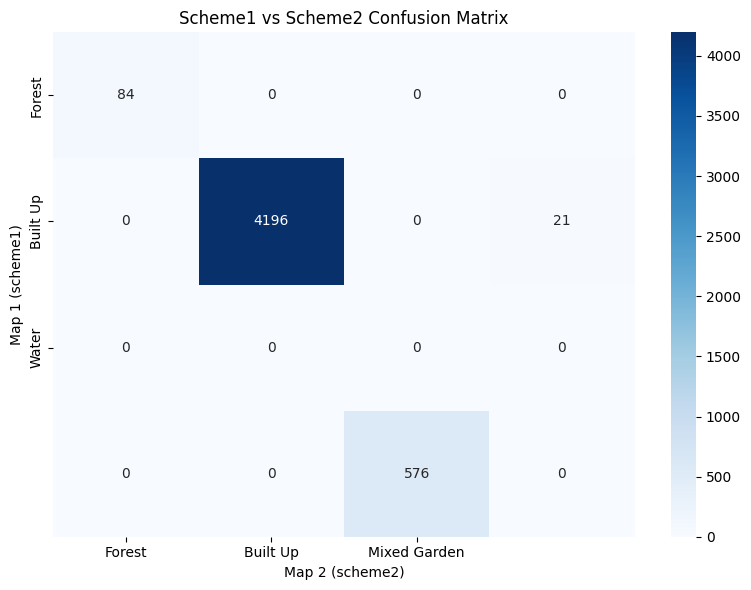

In [24]:
img1 = map1.rename("ref")
img2 = map2.rename("pred")

stacked = img1.addBands(img2)

geom = aoi.geometry()

samples = stacked.sample(
    region=geom,
    scale=30,
    numPixels=5000,
    geometries=False
)


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = samples.errorMatrix("ref", "pred")
cm_info = cm.getInfo()
confusion_matrix = np.array(cm_info)

labels1 = scheme1_rules.sort_values("class_id")["class_name"].tolist()
labels2 = scheme2_rules.sort_values("class_id")["class_name"].tolist()


plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels2,
    yticklabels=labels1
)

plt.title("Scheme1 vs Scheme2 Confusion Matrix")
plt.xlabel("Map 2 (scheme2)")
plt.ylabel("Map 1 (scheme1)")

plt.tight_layout()
plt.show()